**Name: Abeer Fatima**

**Roll no: 22F-BSAI-38**

**Department: BSAI (A1)**

**Subject: Deep Learning**

**Teacher: Sir Hamza**

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv("/content/Clean_Encoded-Data.csv")

In [ ]:
df.head()

,age,apache_2_diagnosis,apache_3j_diagnosis,gcs_eyes_apache,gcs_verbal_apache,heart_rate_apache,resprate_apache,temp_apache,ventilated_apache,d1_diasbp_min,...,apache_2_bodysystem_Cardiovascular,apache_2_bodysystem_Gastrointestinal,apache_2_bodysystem_Haematologic,apache_2_bodysystem_Metabolic,apache_2_bodysystem_Neurologic,apache_2_bodysystem_RenalGenitourinary,apache_2_bodysystem_Respiratory,apache_2_bodysystem_Trauma,apache_2_bodysystem_Undefined Diagnoses,apache_2_bodysystem_Undefined diagnoses
0,23,119,601,4,5,46,52,36,0.0,58,...,False,False,False,False,False,False,False,True,False,False
1,69,301,410,4,5,171,32,35,1.0,45,...,False,False,False,False,True,False,False,False,False,False
2,65,122,409,4,5,104,28,36,0.0,43,...,True,False,False,False,False,False,False,False,False,False
3,85,110,104,4,5,118,40,37,0.0,64,...,True,False,False,False,False,False,False,False,False,False
4,88,301,403,2,4,151,30,35,0.0,66,...,False,False,False,False,True,False,False,False,False,False


In [ ]:
df.shape

(167596, 83)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.532936,0.567871,0.722942,0.718726,0.732578,0.725586


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training Time: 1517.47 seconds



===== ClinicalBERT Full Fine-Tuning =====
Accuracy  : 0.7229
Precision : 0.7187
Recall    : 0.7326
F1-score  : 0.7256

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.71      0.72     16760
           1       0.72      0.73      0.73     16760

    accuracy                           0.72     33520
   macro avg       0.72      0.72      0.72     33520
weighted avg       0.72      0.72      0.72     33520



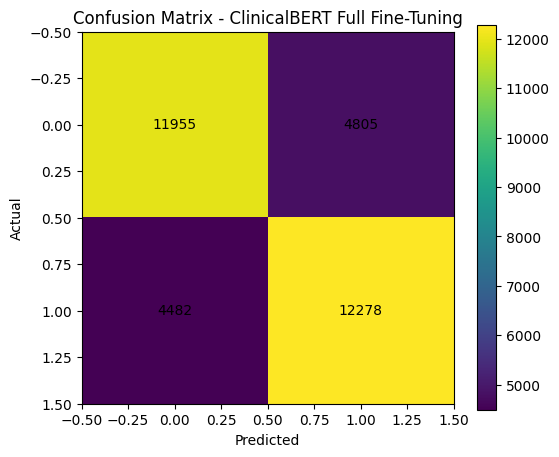

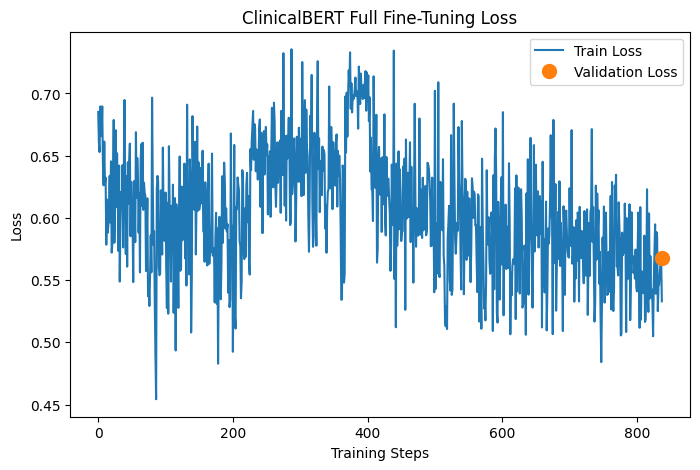

In [ ]:
# CLINICALBERT FULL FINE-TUNING
# IMPORTS
import os
os.environ["WANDB_DISABLED"] = "true"

import time
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

# CREATE CLINICAL NOTES
df = df.copy()

def create_notes(row):
    return (
        f"Patient aged {row['age']}. "
        f"Heart rate {row['heart_rate_apache']}. "
        f"Respiratory rate {row['resprate_apache']}. "
        f"Temperature {row['temp_apache']}. "
        f"GCS eye {row['gcs_eyes_apache']} verbal {row['gcs_verbal_apache']}. "
        f"ICU condition critical status based on vitals and APACHE score."
    )

df["clinical_notes"] = df.apply(create_notes, axis=1)

# SELECT TARGET
TEXT_COL = "clinical_notes"
TARGET = "hospital_death"

df = df[[TEXT_COL, TARGET]].dropna()

# TRAIN TEST SPLIT
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df[TEXT_COL],
    df[TARGET],
    test_size=0.2,
    random_state=42,
    stratify=df[TARGET]
)

# TOKENIZER
MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings = tokenizer(
    list(test_texts),
    truncation=True,
    padding=True,
    max_length=256
)

# DATASET CLASS
class ClinicalDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.values

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(self.labels[idx])

        return item

train_dataset = ClinicalDataset(train_encodings, train_labels)
test_dataset = ClinicalDataset(test_encodings, test_labels)

# LOAD MODEL
# FULL FINE-TUNING
full_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

# METRICS FUNCTION

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    preds = np.argmax(logits, axis=1)

    precision = precision_score(labels, preds)
    recall = recall_score(labels, preds)
    f1 = f1_score(labels, preds)
    accuracy = accuracy_score(labels, preds)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# TRAINING ARGUMENTS
# STORAGE SAFE

args_full = TrainingArguments(
    output_dir="./clinicalbert_full",

    num_train_epochs=1,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_steps=20,

    report_to="none",

    load_best_model_at_end=False
)

# TRAINER
trainer_full = Trainer(
    model=full_model,
    args=args_full,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# TRAIN MODEL
start_time = time.time()

trainer_full.train()

end_time = time.time()

training_time = end_time - start_time

print(f"\nTraining Time: {training_time:.2f} seconds")

# PREDICTIONS
predictions = trainer_full.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_labels.values

# METRICS
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("\n===== ClinicalBERT Full Fine-Tuning =====")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

# CLASSIFICATION REPORT
print("\nClassification Report:\n")

print(classification_report(y_true, y_pred))

# CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.title("Confusion Matrix - ClinicalBERT Full Fine-Tuning")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha='center',
            va='center'
        )

plt.show()

# LOSS CURVES
logs = trainer_full.state.log_history

train_loss = [x["loss"] for x in logs if "loss" in x]
eval_loss = [x["eval_loss"] for x in logs if "eval_loss" in x]

plt.figure(figsize=(8,5))

plt.plot(train_loss, label="Train Loss")

if len(eval_loss) > 0:
    plt.plot(
        [len(train_loss)-1],
        eval_loss,
        marker='o',
        markersize=10,
        linestyle='None',
        label="Validation Loss"
    )

plt.title("ClinicalBERT Full Fine-Tuning Loss")

plt.xlabel("Training Steps")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [ ]:
# ACTUAL VS PREDICTED TABLE
results_df = pd.DataFrame({
    "Actual": y_true,
    "Predicted": y_pred
})
results_df["Match"] = results_df["Actual"] == results_df["Predicted"]
print(results_df.head())

   Actual  Predicted  Match
0       1          1   True
1       1          1   True
2       0          0   True
3       0          0   True
4       0          0   True


ClinicalBERT successfully learned patterns from generated clinical notes and achieved approximately 72% classification accuracy for hospital mortality prediction.

The model demonstrated balanced precision and recall, making it suitable for medical text classification tasks.

Full fine-tuning improved the model’s ability to understand clinical language generated from ICU patient features.